# Práctica - Unidad 1: Extracción y Procesamiento de Texto


**Materia:** Procesamiento de Lenguaje Natural  
**Carrera:** TUIA - Universidad Nacional de Rosario  

---

Esta práctica está diseñada para evaluar y reforzar los conceptos presentados en la unidad de extracción, parseo, limpieza, tokenización, analítica y segmentación de texto.

---

## Parte 0 - Obtención de archivos de ejemplo e instalación de librerías

In [ ]:
!apt-get install poppler-utils tesseract-ocr ffmpeg
!pip install pdf2image PyPDF2 pymupdf pytesseract openai-whisper

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
poppler-utils is already the newest version (22.02.0-2ubuntu0.12).
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
contenido = """
Texto en Latin-1

Palabras con acentos:
á é í ó ú Á É Í Ó Ú

Otros caracteres:
ñ Ñ ü Ü ç Ç

Frase:
El pingüino caminó por la cañería y dijo: Qué frío hace hoy.
"""

with open("archivo_latin1.txt", "w", encoding="iso-8859-1") as f:
    f.write(contenido)

In [ ]:
contenido = """
Texto en UTF-8

Palabras con acentos:
á é í ó ú Á É Í Ó Ú

Otros símbolos:
€ ¥ £

Emojis:
😀 🚀 🌎

Frase:
El pingüino caminó por la cañería y dijo: ¡Qué frío hace hoy!
"""

with open("archivo_utf8.txt", "w", encoding="utf-8") as f:
    f.write(contenido)

In [ ]:
html_content = """<!DOCTYPE html>
<html>
	<head>
	  <title>Este es el título de la página</title>
	</head>
	<body>
	  <p>Este es un párrafo en el cuerpo de la página.</p>
	</body>
</html>
"""

with open("pagina.html", "w", encoding="utf-8") as f:
    f.write(html_content)

In [ ]:
contenido = """
# Ejemplo de Documento Markdown

Este es un **documento de prueba** para convertir de *Markdown a HTML* usando Python.

---

## Encabezados

# Título nivel 1
## Título nivel 2
### Título nivel 3

---

## Formato de texto

Este texto tiene **negrita**, *cursiva*, y también `código en línea`.

---

## Lista desordenada

- Python
- JavaScript
- Rust
- Go

---

## Lista ordenada

1. Aprender Python
2. Aprender scraping
3. Aprender NLP

---

## Enlace

Visita [Hacker News](https://news.ycombinator.com)

---

## Cita

> Markdown es una forma simple de escribir documentos con formato.

---

## Código

```python
def saludar(nombre):
    print(f"Hola {nombre}")

saludar("Constantino")
"""

with open("archivo.md", "w", encoding="utf-8") as f:
    f.write(contenido)

In [ ]:
!wget https://arxiv.org/pdf/1706.03762.pdf -O transformers.pdf

--2026-03-05 21:13:19--  https://arxiv.org/pdf/1706.03762.pdf
Resolving arxiv.org (arxiv.org)... 151.101.131.42, 151.101.3.42, 151.101.195.42, ...
Connecting to arxiv.org (arxiv.org)|151.101.131.42|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: /pdf/1706.03762 [following]
--2026-03-05 21:13:19--  https://arxiv.org/pdf/1706.03762
Reusing existing connection to arxiv.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 2215244 (2.1M) [application/pdf]
Saving to: ‘transformers.pdf’

transformers.pdf    100%[===================>]   2.11M  7.21MB/s    in 0.3s    

2026-03-05 21:13:19 (7.21 MB/s) - ‘transformers.pdf’ saved [2215244/2215244]



In [ ]:
!wget https://arxiv.org/pdf/2302.05105.pdf -O ocr_paper.pdf

--2026-03-05 21:13:20--  https://arxiv.org/pdf/2302.05105.pdf
Resolving arxiv.org (arxiv.org)... 151.101.131.42, 151.101.3.42, 151.101.195.42, ...
Connecting to arxiv.org (arxiv.org)|151.101.131.42|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: /pdf/2302.05105 [following]
--2026-03-05 21:13:20--  https://arxiv.org/pdf/2302.05105
Reusing existing connection to arxiv.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 1234812 (1.2M) [application/pdf]
Saving to: ‘ocr_paper.pdf’

ocr_paper.pdf       100%[===================>]   1.18M  3.54MB/s    in 0.3s    

2026-03-05 21:13:21 (3.54 MB/s) - ‘ocr_paper.pdf’ saved [1234812/1234812]



In [ ]:
!wget https://bookonlinepk.com/cdn/shop/files/b387ad69-4bd0-41f1-b2a2-228826099ffa_grande.jpg -O book_cover.png

--2026-03-05 21:13:21--  https://bookonlinepk.com/cdn/shop/files/b387ad69-4bd0-41f1-b2a2-228826099ffa_grande.jpg
Resolving bookonlinepk.com (bookonlinepk.com)... 23.227.38.32, 2620:127:f00f:3::
Connecting to bookonlinepk.com (bookonlinepk.com)|23.227.38.32|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 55146 (54K) [image/jpeg]
Saving to: ‘book_cover.png’

book_cover.png      100%[===================>]  53.85K  --.-KB/s    in 0s      

2026-03-05 21:13:21 (113 MB/s) - ‘book_cover.png’ saved [55146/55146]



In [ ]:
!wget "https://raw.githubusercontent.com/TinoFerrucci/NLP_files/main/Steve%20Jobs'%202005%20Stanford%20Commencement%20Address.mp4" -O steve_jobs.mp4

--2026-03-05 21:13:21--  https://raw.githubusercontent.com/TinoFerrucci/NLP_files/main/Steve%20Jobs'%202005%20Stanford%20Commencement%20Address.mp4
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 21503433 (21M) [application/octet-stream]
Saving to: ‘steve_jobs.mp4’

steve_jobs.mp4      100%[===================>]  20.51M  44.5MB/s    in 0.5s    

2026-03-05 21:13:22 (44.5 MB/s) - ‘steve_jobs.mp4’ saved [21503433/21503433]



In [ ]:
!ffmpeg -i steve_jobs.mp4 -vn -acodec pcm_s16le -ar 16000 -ac 1 audio.wav

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
!ffmpeg -i audio.wav -t 60 audio_short.wav

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

## Parte 1 - Extracción de texto

### Formato TXT

Este es el formato de archivo de texto más básico. Los archivos TXT solo contienen texto sin formato y no admiten ningún tipo de formato de texto, como negrita, cursiva, colores, etc.

Este es un ejemplo básico de cómo leer un archivo de texto en Python:

In [ ]:
# Abre el archivo en modo de lectura ('r')
with open('archivo_utf8.txt', 'r') as archivo:
    # Lee todo el contenido del archivo
    contenido = archivo.read()

# Imprime el contenido del archivo
print(contenido)


Texto en UTF-8

Palabras con acentos:
á é í ó ú Á É Í Ó Ú

Otros símbolos:
€ ¥ £

Emojis:
😀 🚀 🌎

Frase:
El pingüino caminó por la cañería y dijo: ¡Qué frío hace hoy!



Si intentamos leer otro archivo distinto, que no mantiene el encoding por defecto con la que cuenta la función `open` entonces nos lanzará una excepción.


In [ ]:
try:
    # Abre el archivo en modo de lectura ('r')
    with open('archivo_latin1.txt', 'r') as archivo:
        # Lee todo el contenido del archivo
        contenido = archivo.read()
    # Imprime el contenido del archivo
    print(contenido)
except Exception as e:
    print(str(e))

'utf-8' codec can't decode byte 0xe1 in position 41: invalid continuation byte


Para ello, deberemos pasarle exactamente el encoding correcto aprovechando un parámetro que nos provee la librería.

In [ ]:
with open('archivo_latin1.txt', 'r', encoding='iso-8859-1') as archivo:
    contenido = archivo.read()

print(contenido)


Texto en Latin-1

Palabras con acentos:
á é í ó ú Á É Í Ó Ú

Otros caracteres:
ñ Ñ ü Ü ç Ç

Frase:
El pingüino caminó por la cañería y dijo: Qué frío hace hoy.



### Formato HTML

HTML, que significa Lenguaje de Marcado de Hipertexto (HyperText Markup Language en inglés), es el lenguaje estándar para crear páginas web. HTML utiliza "etiquetas" o "tags" para definir los elementos que componen una página web, como párrafos, encabezados, enlaces, imágenes, listas, tablas, etc. Por ejemplo:



```html
<!DOCTYPE html>
<html>
	<head>
	  <title>Este es el título de la página</title>
	</head>
	<body>
	  <p>Este es un párrafo en el cuerpo de la página.</p>
	</body>
</html>
```



In [ ]:
from IPython.display import HTML

HTML(open("pagina.html").read())

Para leer un archivo HTML y quitar los tags de formateo, podemos usar la libreríaBeautifulSoup en combinación con lxml.

In [ ]:
from bs4 import BeautifulSoup

# Abre el archivo en modo de lectura ('r')
with open('pagina.html', 'r') as archivo:
    # Lee todo el contenido del archivo
    contenido_html = archivo.read()

# Crea un objeto BeautifulSoup
soup = BeautifulSoup(contenido_html, 'lxml')

# Usa el método .text para obtener solo el texto, sin las etiquetas HTML
texto_plano = soup.text

# Imprime el texto plano
print(texto_plano)



Este es el título de la página


Este es un párrafo en el cuerpo de la página.





También podemos utilizarlo para extraer información de páginas WEB, por ejemplo:

In [ ]:
import requests

url = "https://news.ycombinator.com/"
response = requests.get(url)

html = response.text

# imprimir una parte del HTML para no saturar la celda
print(html[:2000])

<html lang="en" op="news"><head><meta name="referrer" content="origin"><meta name="viewport" content="width=device-width, initial-scale=1.0"><link rel="stylesheet" type="text/css" href="news.css?kr8cqFAMakiIVSCfYHGI"><link rel="icon" href="y18.svg"><link rel="alternate" type="application/rss+xml" title="RSS" href="rss"><title>Hacker News</title></head><body><center><table id="hnmain" border="0" cellpadding="0" cellspacing="0" width="85%" bgcolor="#f6f6ef"><tr><td bgcolor="#ff6600"><table border="0" cellpadding="0" cellspacing="0" width="100%" style="padding:2px"><tr><td style="width:18px;padding-right:4px"><a href="https://news.ycombinator.com"><img src="y18.svg" width="18" height="18" style="border:1px white solid; display:block"></a></td><td style="line-height:12pt; height:10px;"><span class="pagetop"><b class="hnname"><a href="news">Hacker News</a></b><a href="newest">new</a> | <a href="front">past</a> | <a href="newcomments">comments</a> | <a href="ask">ask</a> | <a href="show">sho

Viendo la estructura de este código HTML vemos que está más enriquecido, veamos que podemos hacer a partir de la siguiente imagen:

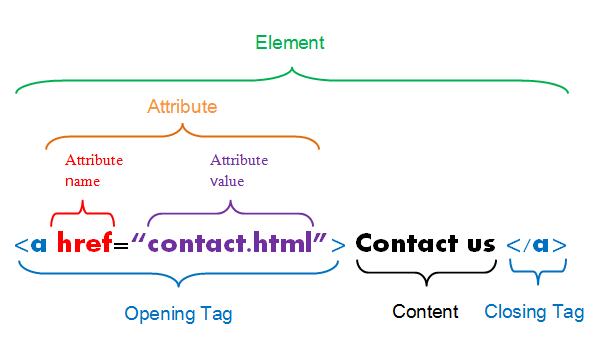

Podemos recuperar las ultimas noticias a traves de su atributo clase "timeline" y su etiqueta "a"

In [ ]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(html, "lxml")

titulos = soup.select(".titleline a")

for i, titulo in enumerate(titulos[::2][:10], start=1):
    print(f"{i}. {titulo.text}")

1. GPT-5.4
2. Wikipedia in read-only mode following mass admin account compromise
3. The Brand Age
4. Pentagon Formally Labels Anthropic Supply-Chain Risk
5. Let's Get Physical
6. Structured AI (YC F25) Is Hiring
7. Hardware hotplug events on Linux, the gory details
8. Good software knows when to stop
9. A GitHub Issue Title Compromised 4k Developer Machines
10. Show HN: Jido 2.0, Elixir Agent Framework


En caso de querer obtener su atributo "href", también podremos hacerlo:

In [ ]:
for i, titulo in enumerate(titulos[::2][:10], start=1):
    texto = titulo.text
    link = titulo["href"]

    print(f"{i}. {texto}")
    print(f"   {link}\n")

1. GPT-5.4
   https://openai.com/index/introducing-gpt-5-4/

2. Wikipedia in read-only mode following mass admin account compromise
   https://www.wikimediastatus.net

3. The Brand Age
   https://paulgraham.com/brandage.html

4. Pentagon Formally Labels Anthropic Supply-Chain Risk
   https://www.wsj.com/politics/national-security/pentagon-formally-labels-anthropic-supply-chain-risk-escalating-conflict-ebdf0523

5. Let's Get Physical
   https://m4iler.cloud/posts/lets-get-physical/

6. Structured AI (YC F25) Is Hiring
   https://www.ycombinator.com/companies/structured-ai/jobs/3cQY6Cu-mechanical-design-engineer-founding-team-consultant

7. Hardware hotplug events on Linux, the gory details
   https://arcanenibble.github.io/hardware-hotplug-events-on-linux-the-gory-details.html

8. Good software knows when to stop
   https://ogirardot.writizzy.com/p/good-software-knows-when-to-stop

9. A GitHub Issue Title Compromised 4k Developer Machines
   https://grith.ai/blog/clinejection-when-your-

### Formato MarkDown

Los archivos de Markdown son archivos de texto con una sintaxis especial para formatear el texto. Este formato es popular en el mundo del desarrollo de software, ya que es el predeterminado para documentar código fuente en Github.

In [ ]:
with open("archivo.md", "r", encoding="utf-8") as f:
    contenido = f.read()

print(contenido)


# Ejemplo de Documento Markdown

Este es un **documento de prueba** para convertir de *Markdown a HTML* usando Python.

---

## Encabezados

# Título nivel 1
## Título nivel 2
### Título nivel 3

---

## Formato de texto

Este texto tiene **negrita**, *cursiva*, y también `código en línea`.

---

## Lista desordenada

- Python
- JavaScript
- Rust
- Go

---

## Lista ordenada

1. Aprender Python
2. Aprender scraping
3. Aprender NLP

---

## Enlace

Visita [Hacker News](https://news.ycombinator.com)

---

## Cita

> Markdown es una forma simple de escribir documentos con formato.

---

## Código

```python
def saludar(nombre):
    print(f"Hola {nombre}")

saludar("Constantino")



Si lo imprimimos con formato, veremos lo siguiente

In [ ]:
from IPython.display import Markdown, display

# Leer el archivo markdown
with open("archivo.md", "r", encoding="utf-8") as f:
    contenido = f.read()

# Mostrarlo renderizado
display(Markdown(contenido))


# Ejemplo de Documento Markdown

Este es un **documento de prueba** para convertir de *Markdown a HTML* usando Python.

---

## Encabezados

# Título nivel 1
## Título nivel 2
### Título nivel 3

---

## Formato de texto

Este texto tiene **negrita**, *cursiva*, y también `código en línea`.

---

## Lista desordenada

- Python
- JavaScript
- Rust
- Go

---

## Lista ordenada

1. Aprender Python
2. Aprender scraping
3. Aprender NLP

---

## Enlace

Visita [Hacker News](https://news.ycombinator.com)

---

## Cita

> Markdown es una forma simple de escribir documentos con formato.

---

## Código

```python
def saludar(nombre):
    print(f"Hola {nombre}")

saludar("Constantino")


### Formato PDF

El formato de archivo PDF (Portable Document Format) fue desarrollado por Adobe Systems. Es un formato de archivo universal que preserva las fuentes, las imágenes, los gráficos y el diseño de cualquier documento fuente, independientemente de la aplicación y la plataforma utilizadas para crearlo.

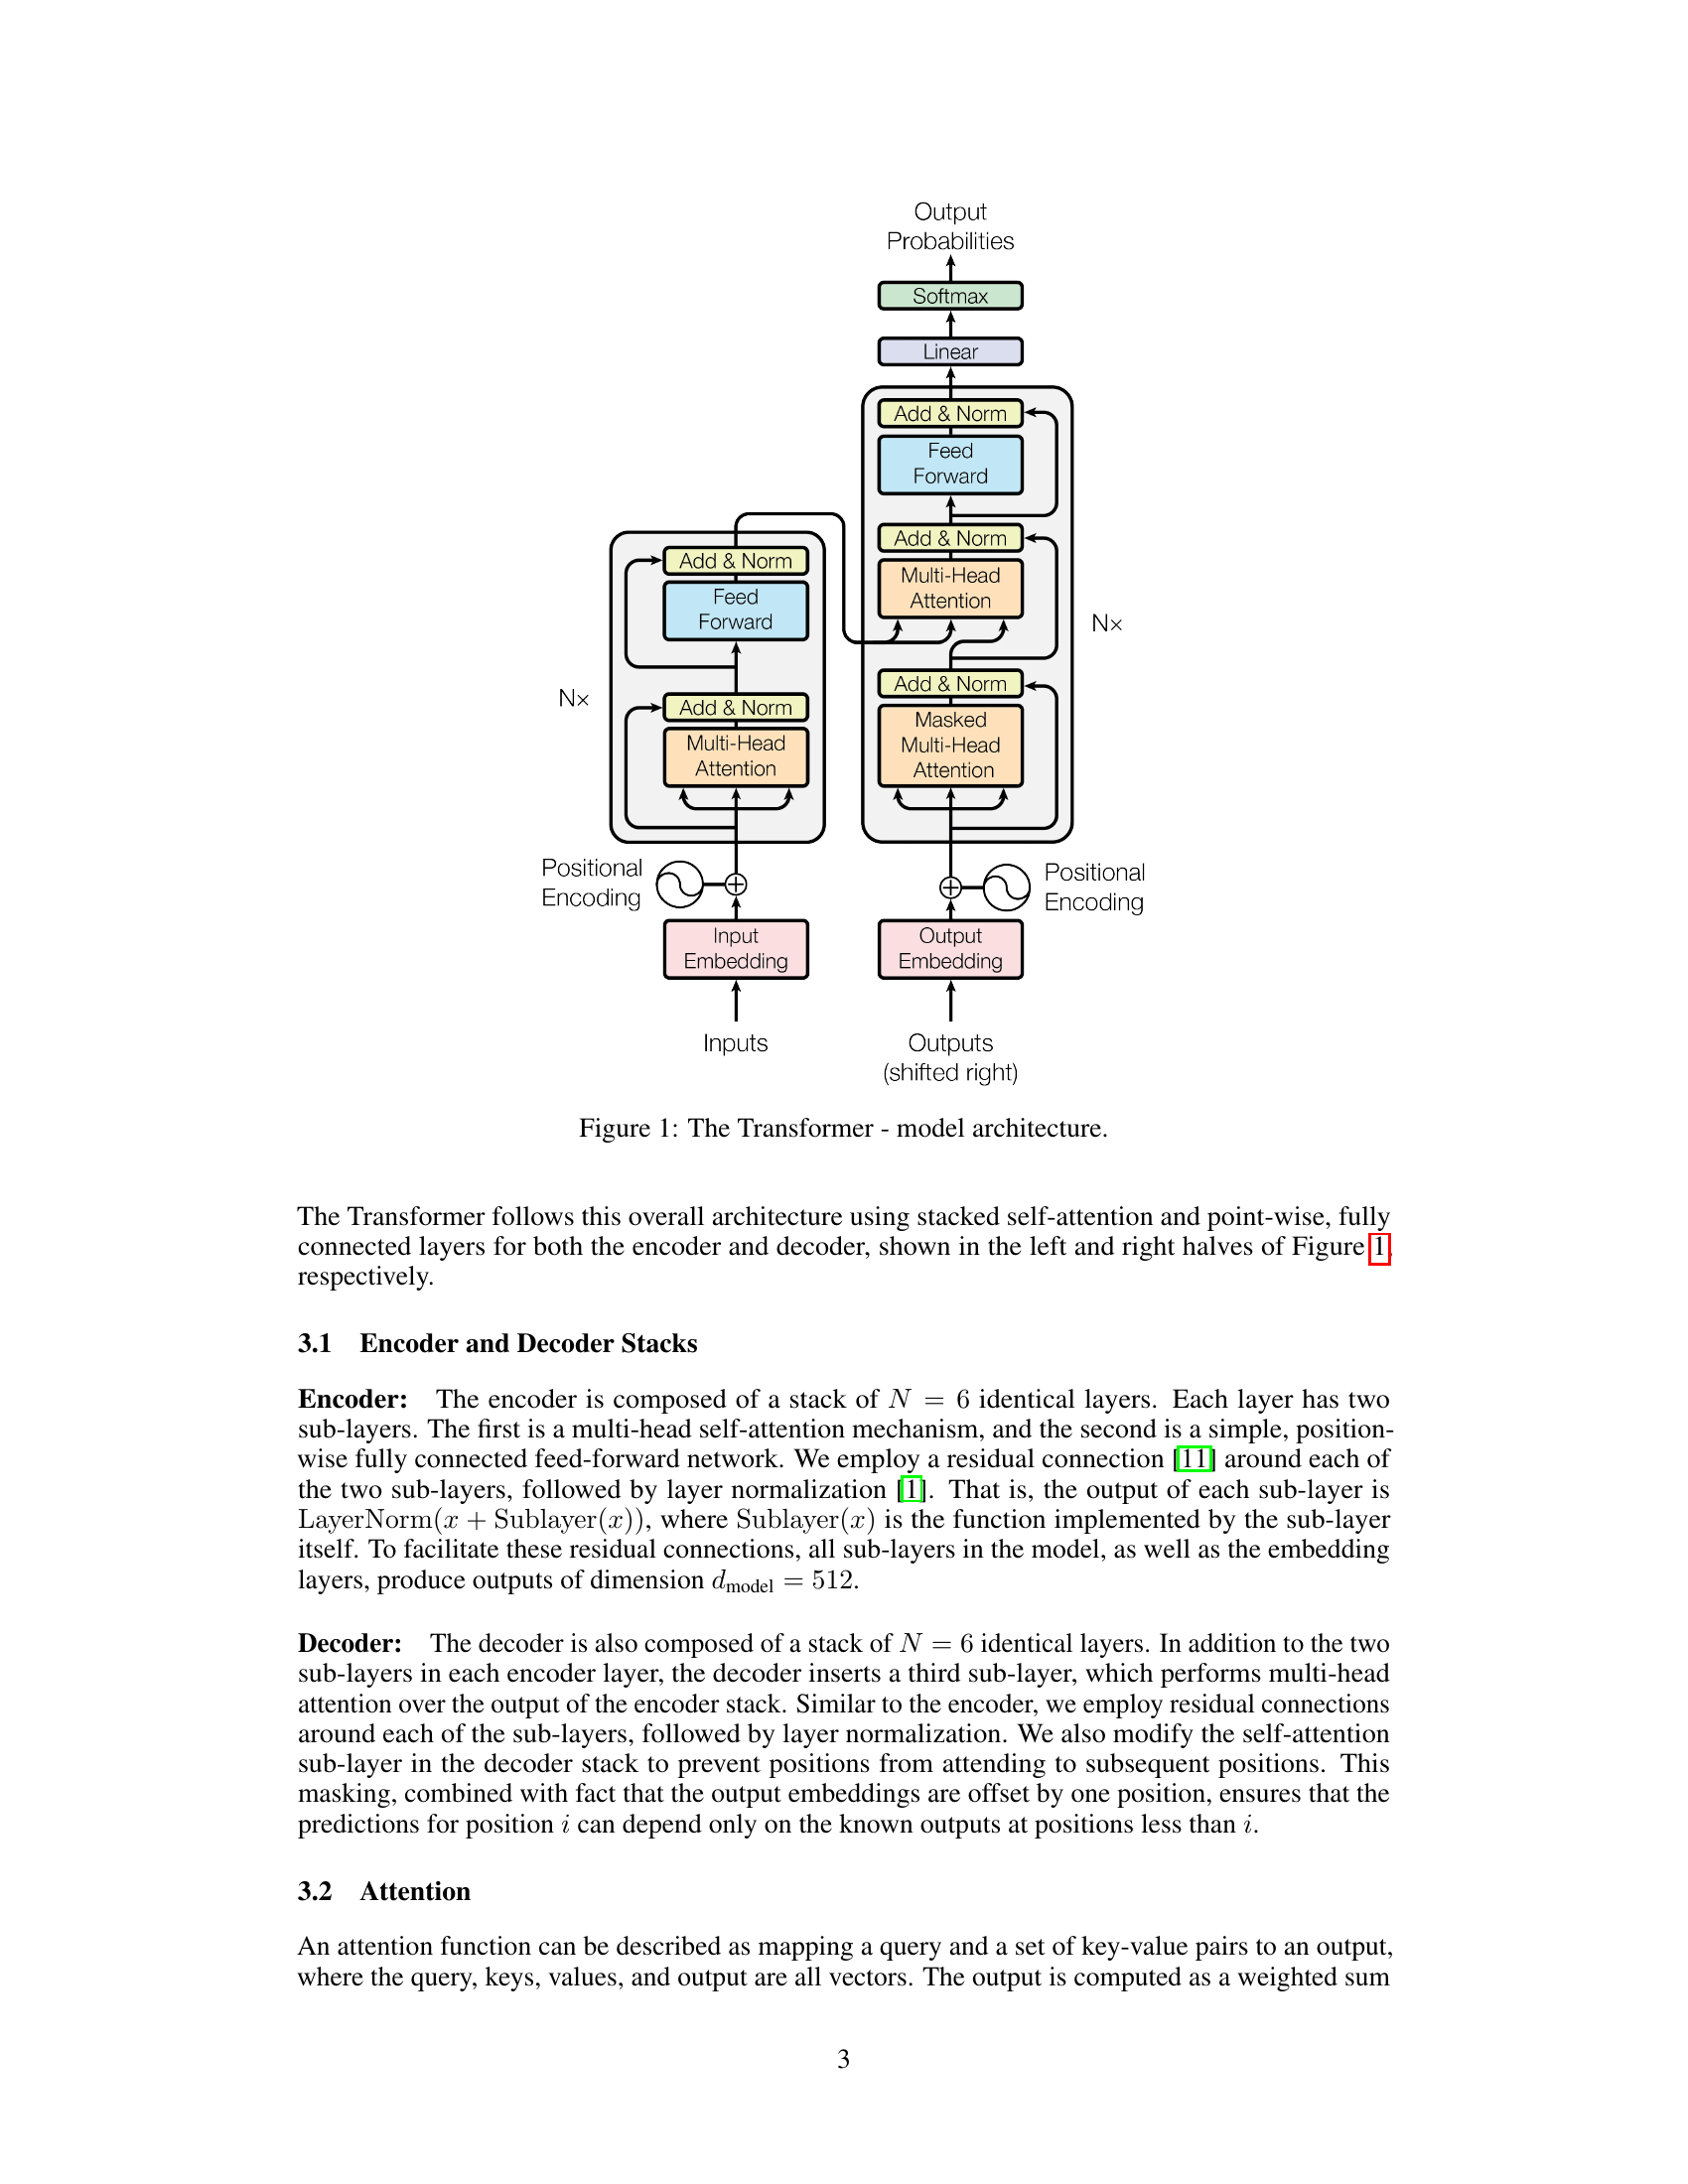

In [ ]:
from pdf2image import convert_from_path
from IPython.display import display

# Convertir solo la primera página
imagenes = convert_from_path("transformers.pdf", first_page=3, last_page=3)

# Mostrar la imagen
display(imagenes[0])

In [ ]:
import PyPDF2

with open("transformers.pdf", "rb") as archivo:

    lector = PyPDF2.PdfReader(archivo)

    pagina_1 = lector.pages[0]

    texto = pagina_1.extract_text()

print(texto)

Provided proper attribution is provided, Google hereby grants permission to
reproduce the tables and figures in this paper solely for use in journalistic or
scholarly works.
Attention Is All You Need
Ashish Vaswani∗
Google Brain
avaswani@google.comNoam Shazeer∗
Google Brain
noam@google.comNiki Parmar∗
Google Research
nikip@google.comJakob Uszkoreit∗
Google Research
usz@google.com
Llion Jones∗
Google Research
llion@google.comAidan N. Gomez∗ †
University of Toronto
aidan@cs.toronto.eduŁukasz Kaiser∗
Google Brain
lukaszkaiser@google.com
Illia Polosukhin∗ ‡
illia.polosukhin@gmail.com
Abstract
The dominant sequence transduction models are based on complex recurrent or
convolutional neural networks that include an encoder and a decoder. The best
performing models also connect the encoder and decoder through an attention
mechanism. We propose a new simple network architecture, the Transformer,
based solely on attention mechanisms, dispensing with recurrence and convolutions
entirely. Experime

Podemos también extaer imágenes del PDF

In [ ]:
import fitz  # PyMuPDF
from PIL import Image
import io
from IPython.display import display

pdf = fitz.open("transformers.pdf")

In [ ]:
pagina = pdf[2]
print(pagina.get_text())

Figure 1: The Transformer - model architecture.
The Transformer follows this overall architecture using stacked self-attention and point-wise, fully
connected layers for both the encoder and decoder, shown in the left and right halves of Figure 1,
respectively.
3.1
Encoder and Decoder Stacks
Encoder:
The encoder is composed of a stack of N = 6 identical layers. Each layer has two
sub-layers. The first is a multi-head self-attention mechanism, and the second is a simple, position-
wise fully connected feed-forward network. We employ a residual connection [11] around each of
the two sub-layers, followed by layer normalization [1]. That is, the output of each sub-layer is
LayerNorm(x + Sublayer(x)), where Sublayer(x) is the function implemented by the sub-layer
itself. To facilitate these residual connections, all sub-layers in the model, as well as the embedding
layers, produce outputs of dimension dmodel = 512.
Decoder:
The decoder is also composed of a stack of N = 6 identical layers. 

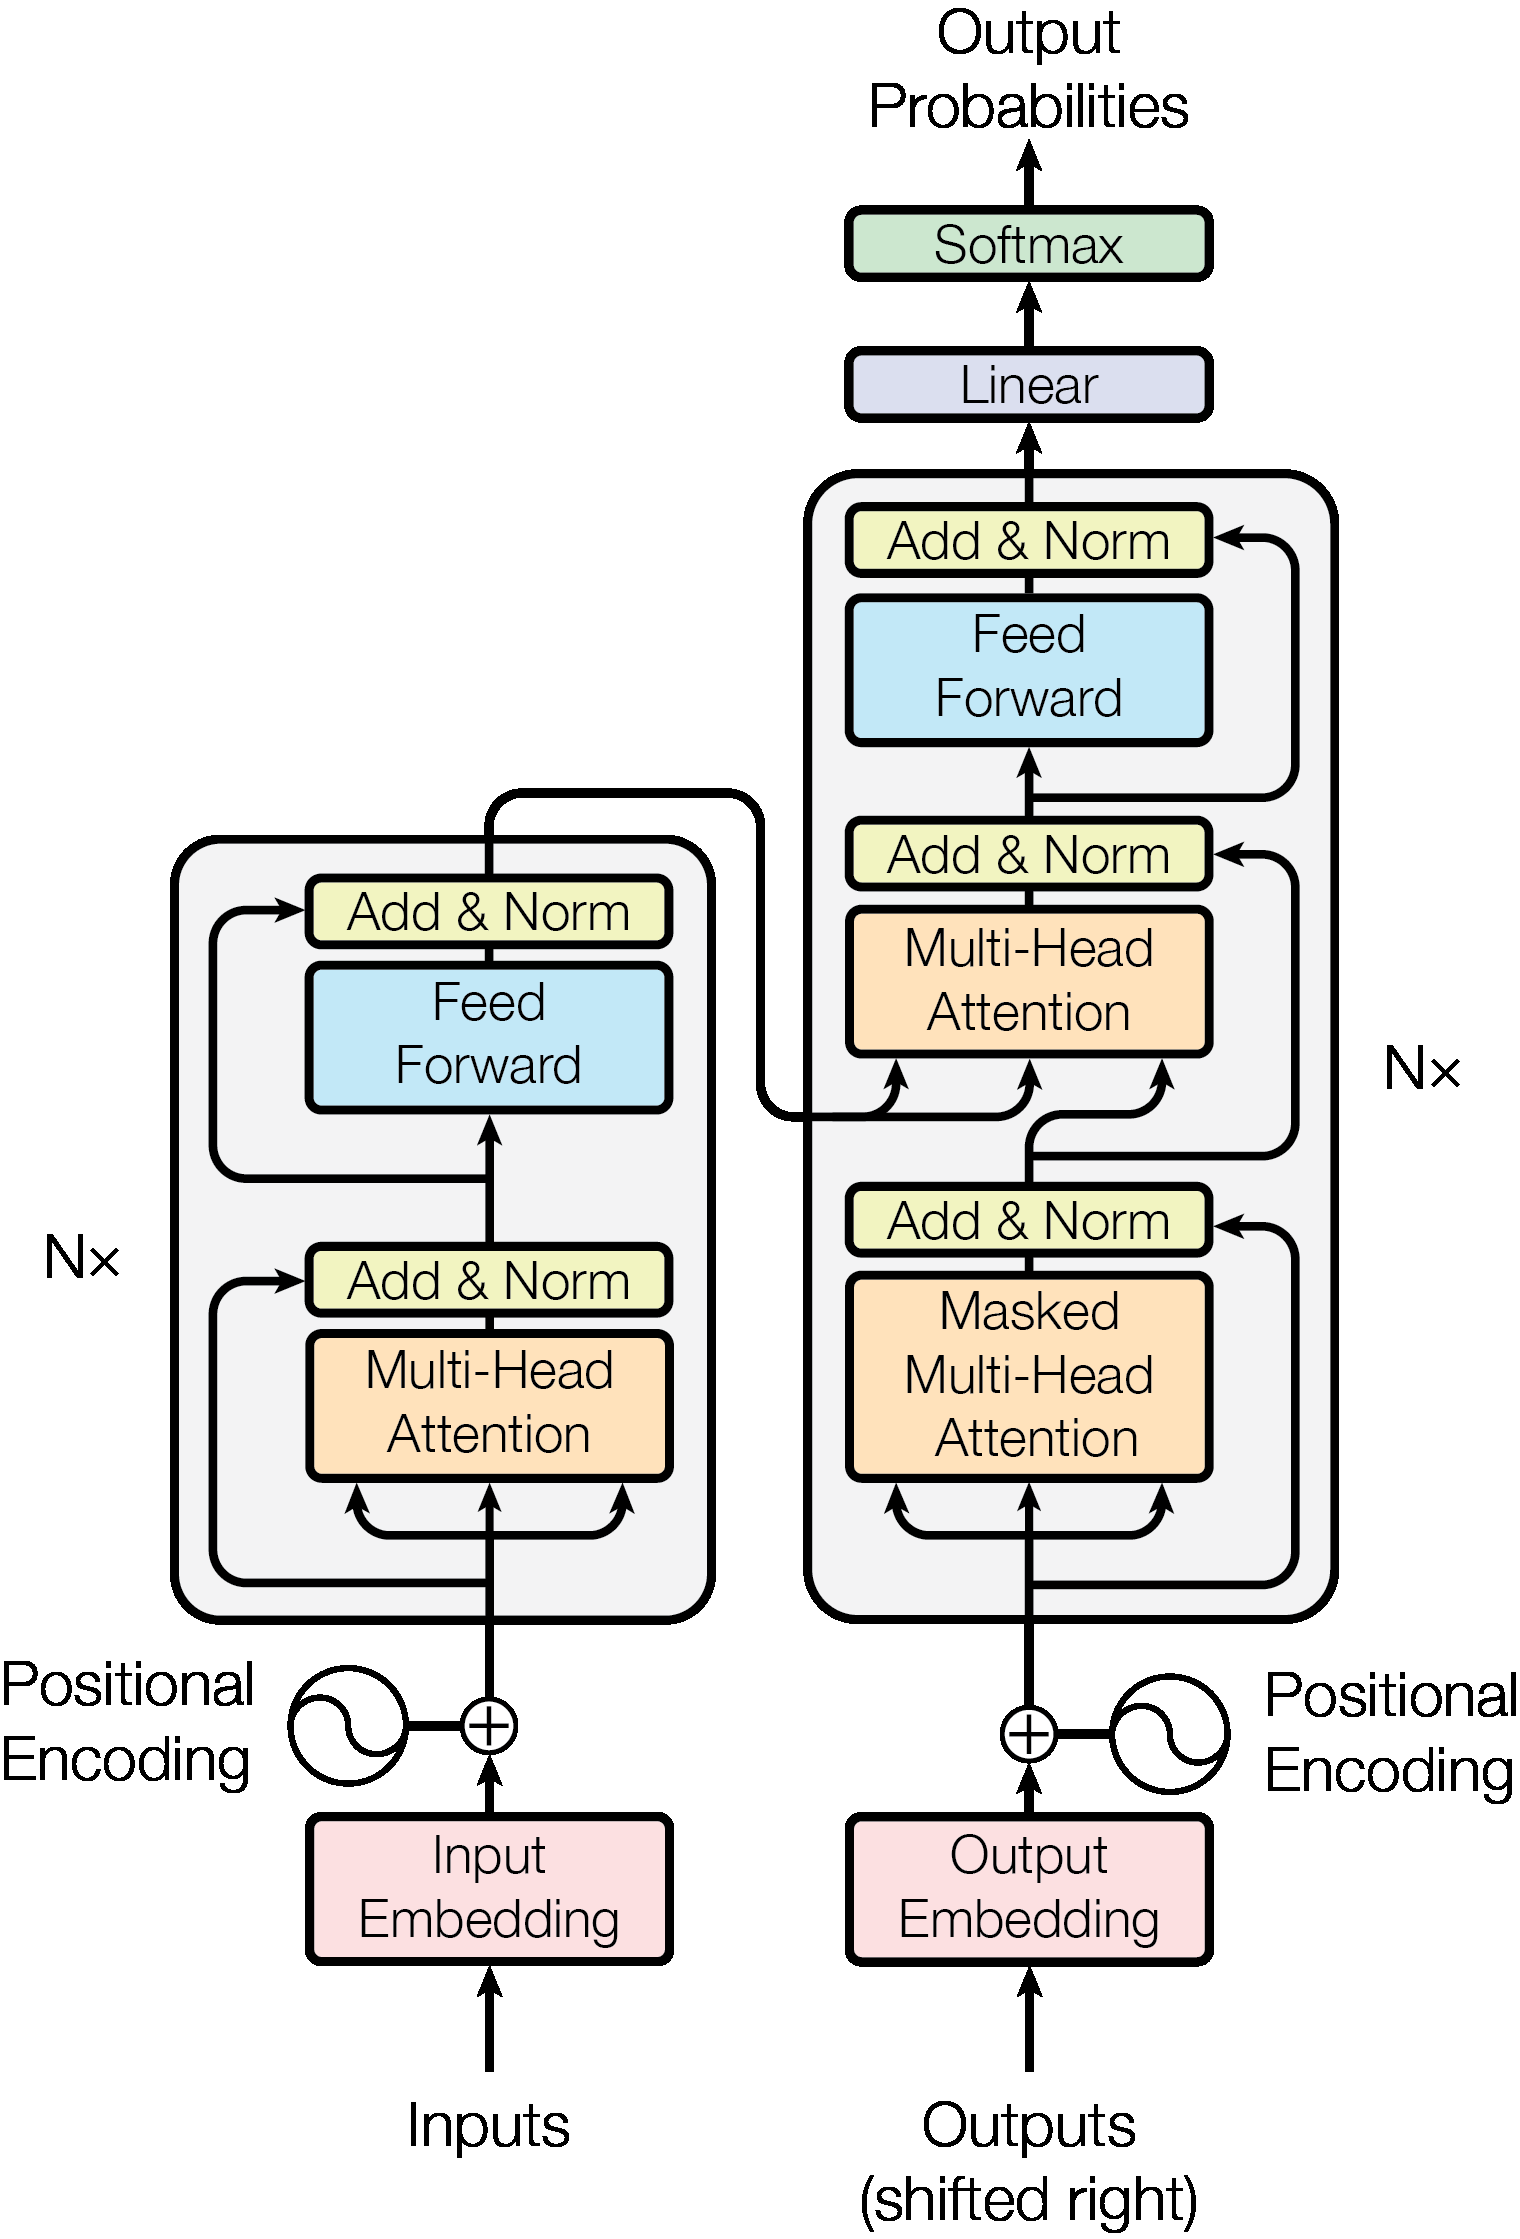

In [ ]:
imagenes = pagina.get_images(full=True)

for img in imagenes:
    xref = img[0]
    base_image = pdf.extract_image(xref)
    image = Image.open(io.BytesIO(base_image["image"]))
    display(image)

También podemos extraer los bloques en orden y aprovecharlo para ver si contienen imágenes y así ordenarlas a la hora de extraer esto

[IMAGEN]


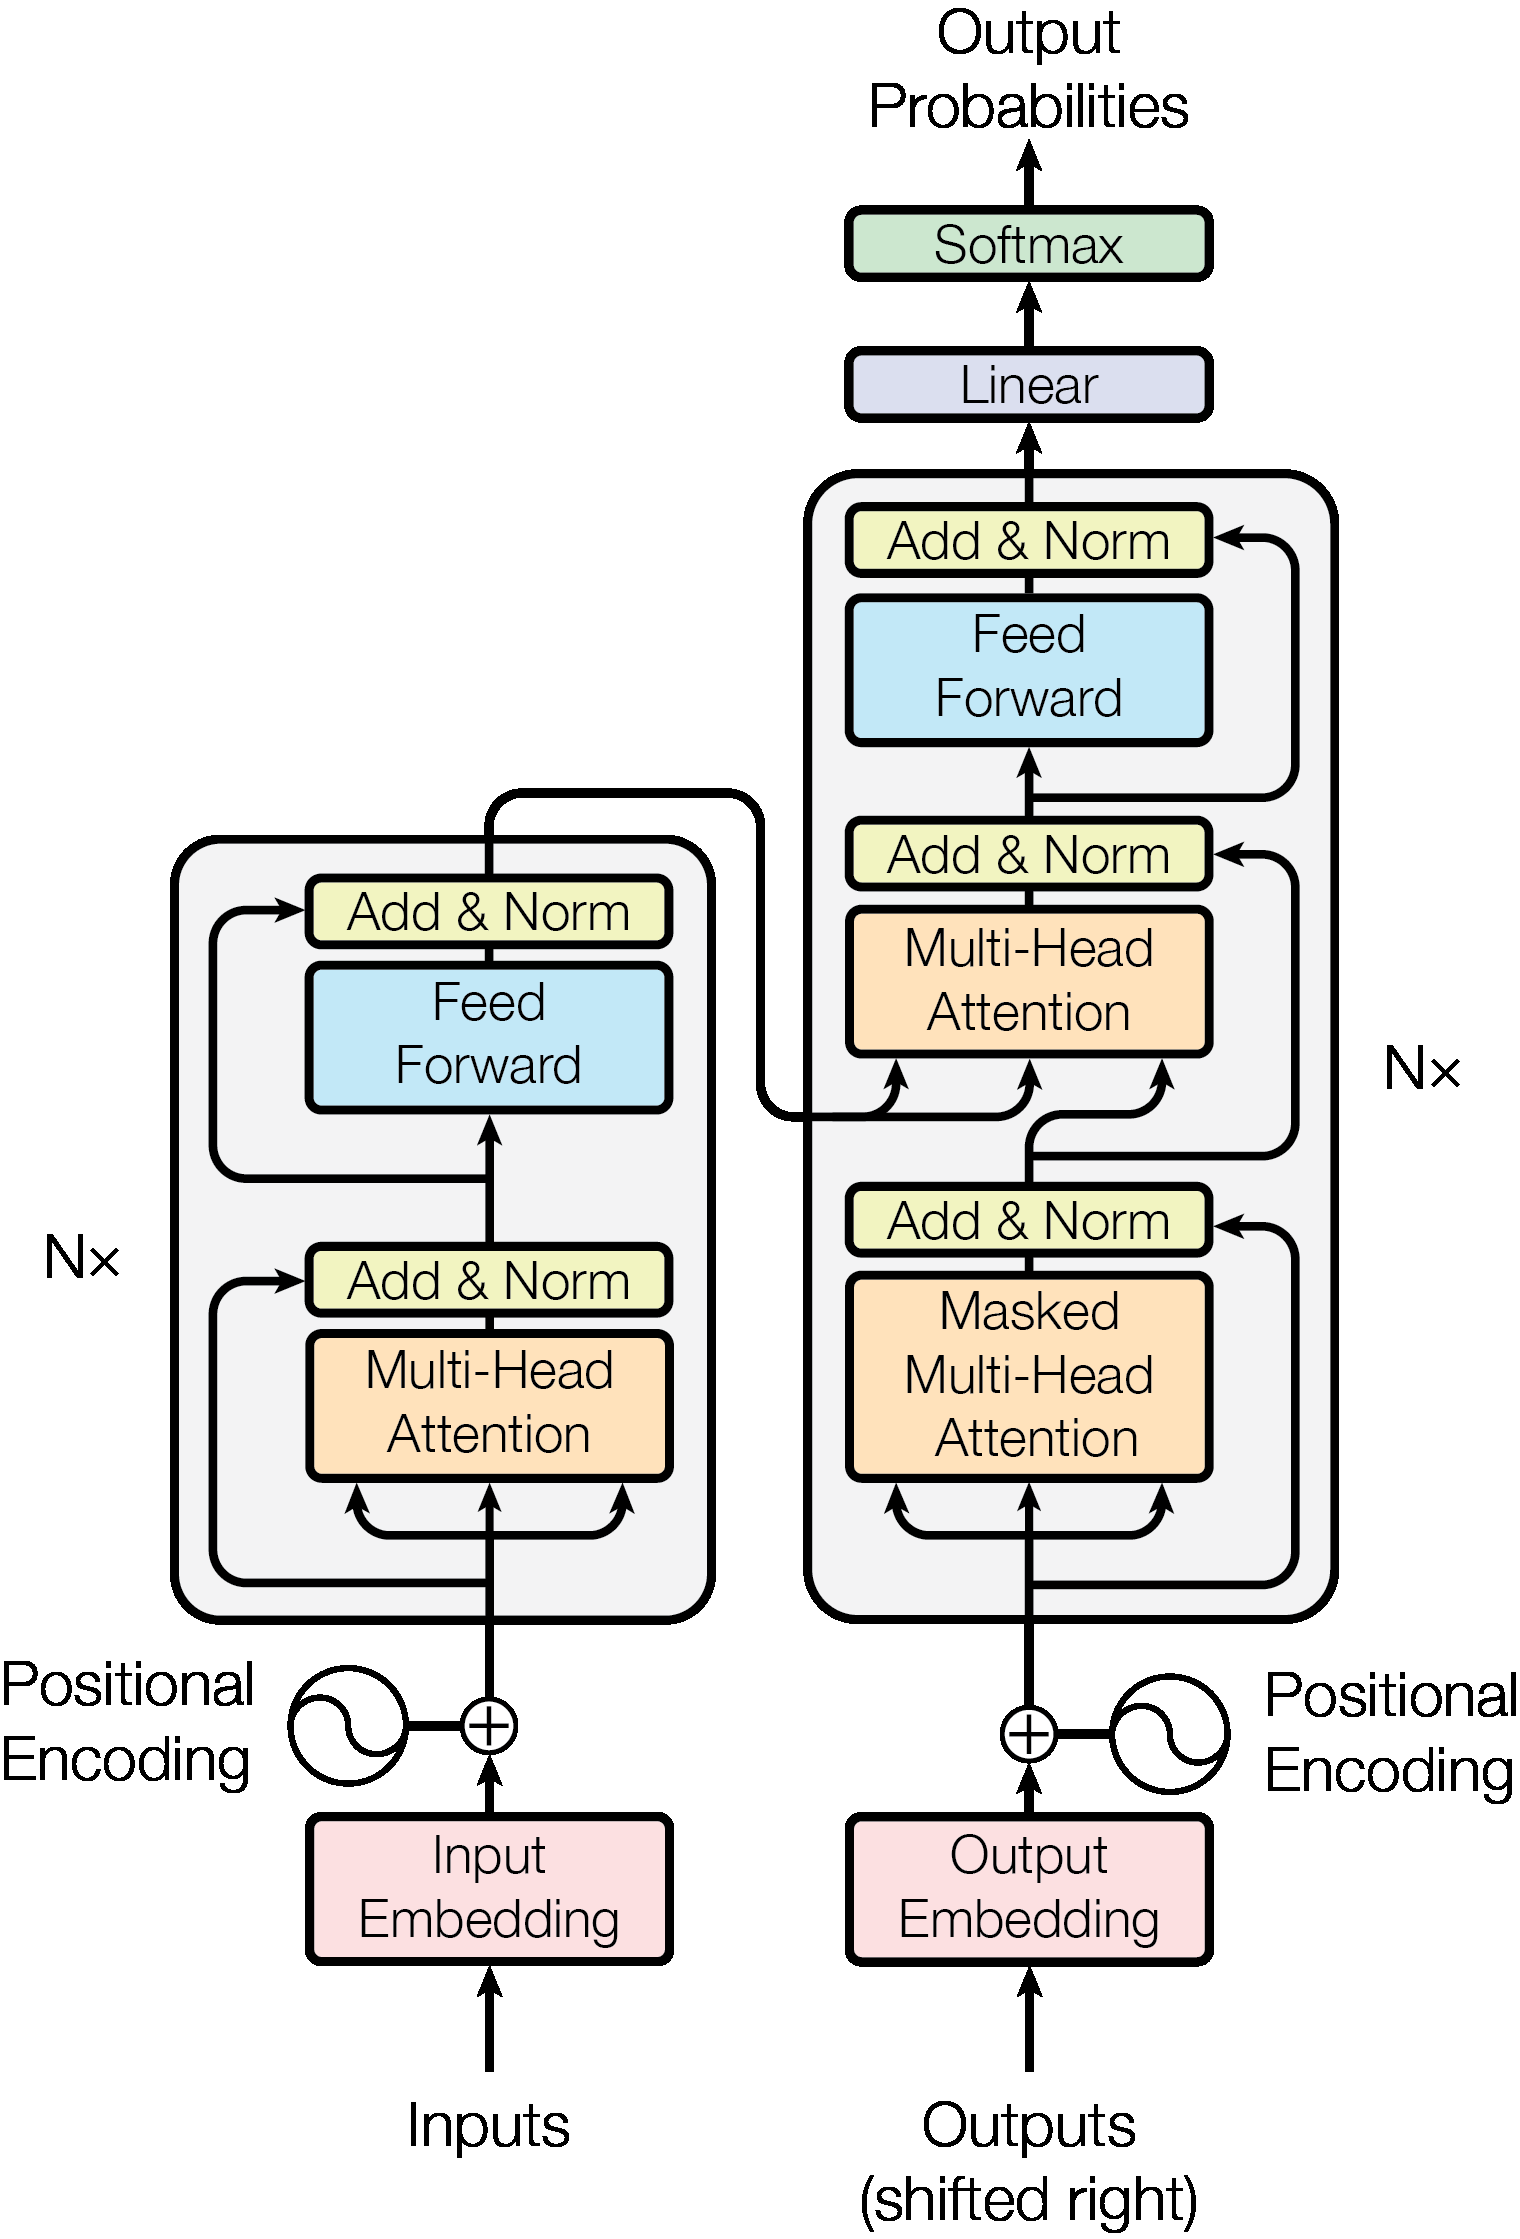

Figure 1: The Transformer - model architecture.

The Transformer follows this overall architecture using stacked self-attention and point-wise, fully
connected layers for both the encoder and decoder, shown in the left and right halves of Figure 1,
respectively.

3.1
Encoder and Decoder Stacks

Encoder:
The encoder is composed of a stack of N = 6 identical layers. Each layer has two
sub-layers. The first is a multi-head self-attention mechanism, and the second is a simple, position-
wise fully connected feed-forward network. We employ a residual connection [11] around each of
the two sub-layers, followed by layer normalization [1]. That is, the output of each sub-layer is
LayerNorm(x + Sublayer(x)), where Sublayer(x) is the function implemented by the sub-layer
itself. To facilitate these residual connections, all sub-layers in the model, as well as the embedding
layers, produce outputs of dimension dmodel = 512.

Decoder:
The decoder is also composed of a stack of N = 6 identical laye

In [ ]:
page = pdf[2]

# Obtener bloques en orden
blocks = page.get_text("dict")["blocks"]

for block in blocks:

    # BLOQUE DE TEXTO
    if block["type"] == 0:
        texto = ""
        for line in block["lines"]:
            for span in line["spans"]:
                texto += span["text"]
            texto += "\n"

        print(texto)

    # BLOQUE DE IMAGEN
    elif block["type"] == 1:
        img_bytes = block["image"]
        img = Image.open(io.BytesIO(img_bytes))

        print("[IMAGEN]")
        display(img)

### Formato JPG, PNG, ... (Imágenes)

Para poder obtener el texto en estos casos, necesitaremos de una herramienta de tipo OCR (Optical Character Recognition). Para convertir una imagen a texto en Python, podemos usar la librería pytesseract, que es un wrapper (envoltorio) para Tesseract OCR. Aquí vemos un ejemplo de cómo hacerlo:

In [ ]:
from PIL import Image
import pytesseract

# Ruta a la imagen
archivo_imagen = 'book_cover.png'

# Abre la imagen
imagen = Image.open(archivo_imagen)

# Usa pytesseract para convertir la imagen en texto
# Podemos especificar los idiomas posibles del documento:
texto = pytesseract.image_to_string(imagen, lang="eng+spa+fra")

# Imprime el texto extraído
print(texto)

 

 

‘

Py,
O'REILLY® ca a

%

os

Hands-on

Machine Learning
with Scikit-Learn,
Keras & TensorFlow

Concepts, Tools, and Techniques
to Build Intelligent Systems

powered by

 
    
  
 

ams
Jupyter
~—

Aurélien Géron

 

 



(np.float64(-0.5), np.float64(456.5), np.float64(599.5), np.float64(-0.5))

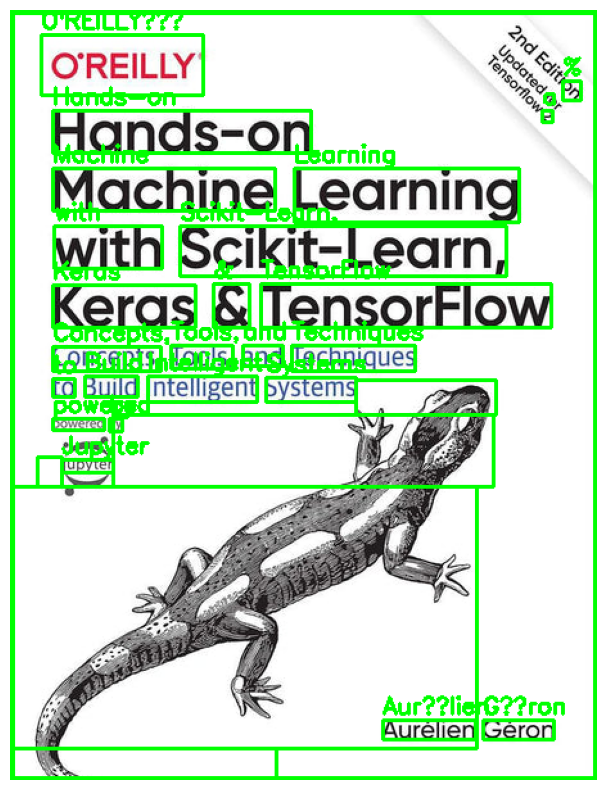

In [ ]:
import pytesseract
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar imagen
imagen = cv2.imread("book_cover.png")

# Convertir a RGB (OpenCV usa BGR)
rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

# Obtener datos OCR
datos = pytesseract.image_to_data(rgb, lang="eng+spa+fra", output_type=pytesseract.Output.DICT)

# Dibujar recuadros
n = len(datos["text"])

for i in range(n):

    texto = datos["text"][i]
    conf = int(datos["conf"][i])

    if conf > 50:  # filtrar detecciones malas

        x = datos["left"][i]
        y = datos["top"][i]
        w = datos["width"][i]
        h = datos["height"][i]

        cv2.rectangle(rgb, (x, y), (x+w, y+h), (0,255,0), 2)
        cv2.putText(rgb, texto, (x, y-5),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6, (0,255,0), 2)

# Mostrar resultado
plt.figure(figsize=(8,10))
plt.imshow(rgb)
plt.axis("off")

### Formato wav, MP3 (Audio)

In [ ]:
from IPython.display import Audio
Audio("audio_short.wav")

In [ ]:
import whisper

# Cargar modelo
model = whisper.load_model("base")

# Transcribir audio
resultado = model.transcribe("audio_short.wav")

# Mostrar texto
print(resultado["text"])

/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


 This program is brought to you by Stanford University. Please visit us at stanford.edu. Thank you. I'm honored to be with you today for your commencement from one of the finest universities in the world. Truth be told, I never graduated from college and this is the closest I've ever gotten to a college graduation. Today I want to tell you three stories from my life. That's it. No big deal. Just three stories. The first story is about connecting the dots.


In [ ]:
for segmento in resultado["segments"]:
    print(f"[{segmento['start']:.2f} - {segmento['end']:.2f}] {segmento['text']}")

[0.00 - 21.44]  This program is brought to you by Stanford University. Please visit us at stanford.edu.
[21.44 - 34.00]  Thank you. I'm honored to be with you today for your commencement from one of the finest universities in the world.
[34.00 - 47.44]  Truth be told, I never graduated from college and this is the closest I've ever gotten to a college graduation.
[47.84 - 54.08]  Today I want to tell you three stories from my life. That's it. No big deal. Just three stories.
[55.68 - 65.12]  The first story is about connecting the dots.


## Ejercicios Parte 1

Apoyandose en este material y en el apunte de la [UNIDAD 1](https://www.notion.so/Unidad-1-Extracci-n-y-Procesamiento-de-Texto-25f15e55f7ac4e1096376b060df1837f?pvs=97#c7c41c9403674610bba9b5b54778ddb6) resolver:

### Ejercicio 1

Utilizando la librería BeautifoulSoup:

A) Extraer solo el texto de los párrafos con class="contenido"

B) Extraer el título de la página

C) Obtener todo el texto sin etiquetas HTML

In [ ]:
from bs4 import BeautifulSoup
html_ejemplo = """
<!DOCTYPE html>
<html>
<head><title>Ejercicio de prueba 1.2</title></head>
    <body>
    <h1>Título Principal</h1>
    <p class="contenido">Este es el <strong>primer</strong> párrafo.</p>
    <p class="contenido">Este es el <em>segundo</em> párrafo.</p>
    <div class="nota">
        <p>Esta es una nota especial</p>
    </div>
    </body>
</html>
"""

### Ejercicio 2


Para este ejercicio vamos a consultar a el sitio web [Hacker News](https://news.ycombinator.com) y vamos a:

A) Obtener las ultimas 100 noticias de este sitio, investigar como manipular la URL para poder acceder a otras páginas del sitio.

B) Obtener la URL de las ultimas 100 noticias e imprimirlas junto a los títulos de las mismas.

C) Extraer datos extras como el usuario, cantidad de puntos, comentarios y tiempo de subida de la noticia.

### Ejercicio 3

En este ejercicio obtendremos la información de un [paper](https://arxiv.org/pdf/2302.05105), el cual está almacenado ya en este mismo entorno de ejecución como **OCR_PAPER**, para ello:

A) Vamos a comparar la extracción de texto con al menos 2 librerías vistas en la teoría y comparar sus resultados.

B) Obtener imágenes de las mismas e imprimir junto a su texto.

C) Tomar una página de referencia e imprimirla (recomendación página 2) en orden junto con imagenes y texto.

D) Tomar la imagen y hacer OCR de la misma, investigar mediante lo visto en la teoría y en este recurso, como obtener el texto de esa imagen e integrarlo en el mismo orden en el contenido del PDF.

### Ejercicio 4

Extracción (Wikipedia). El objetivo es comprender como obtener el contenido de varios lugares para enriquecer nuestra información.

A) Utilizando la librería wikipedia-api , extrae el contenido completo de la página de Wikipedia sobre "Inteligencia artificial" estableciendo el idioma en español.